In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='muted')
import warnings
warnings.simplefilter("ignore")
np.random.seed(99)

# Load Data

In [2]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

# EDA

In [3]:
# useful functions

def get_NaN(df):
    N = df.shape[0]
    ndf = pd.DataFrame({'any NaN': df.apply(lambda x: x.isna().any()),  
                        '# NaN': df.apply(lambda x: x.isna().sum()), 
                        '% NaN': df.apply(lambda x: x.isna().sum() / N * 100),
                        '# unique': df.apply(lambda x: x.nunique())
                        })
    ndf['% NaN'] = np.round(ndf['% NaN'], 1)
    return ndf
        
        
def plot_dist(df, feat):
    fig, ax = plt.subplots(1, 2, figsize=(18,4))
    for i, n in enumerate(['no', 'yes']):
        y = df[df['Survived']==i][feat]
        sns.distplot(y, ax=ax[0], label=n)
        sns.distplot(np.log1p(y), ax=ax[1], label=n)
    ax[0].legend()
    ax[1].legend()
    ax[1].set_xlabel(f'log1p {feat}')

## <p style='color:blue'> General Information </p>

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## <p style='color:blue'> Missing Values </p>

In [6]:
# train set
get_NaN(train)

,any NaN,# NaN,% NaN,# unique
PassengerId,False,0,0.0,891
Survived,False,0,0.0,2
Pclass,False,0,0.0,3
Name,False,0,0.0,891
Sex,False,0,0.0,2
Age,True,177,19.9,88
SibSp,False,0,0.0,7
Parch,False,0,0.0,7
Ticket,False,0,0.0,681
Fare,False,0,0.0,248


In [7]:
# test set
get_NaN(test)

,any NaN,# NaN,% NaN,# unique
PassengerId,False,0,0.0,418
Pclass,False,0,0.0,3
Name,False,0,0.0,418
Sex,False,0,0.0,2
Age,True,86,20.6,79
SibSp,False,0,0.0,7
Parch,False,0,0.0,8
Ticket,False,0,0.0,363
Fare,True,1,0.2,169
Cabin,True,327,78.2,76


## <p style='color:blue'> Target </p>

0    0.616162
1    0.383838
Name: Survived, dtype: float64

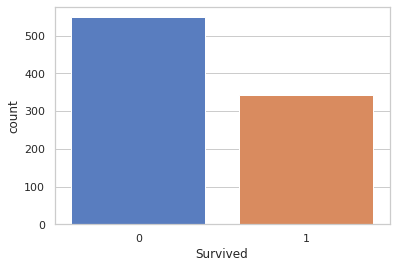

In [8]:
sns.countplot(train['Survived']);

train['Survived'].value_counts() / len(train)

## <p style='color:blue'> Categorical Features </p>

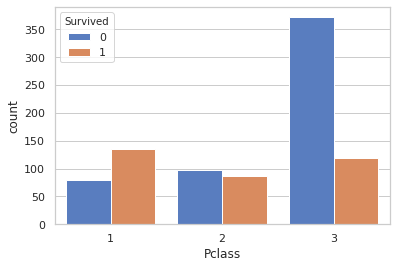

In [9]:
# Pclass
sns.countplot(x='Pclass', hue='Survived', data=train);

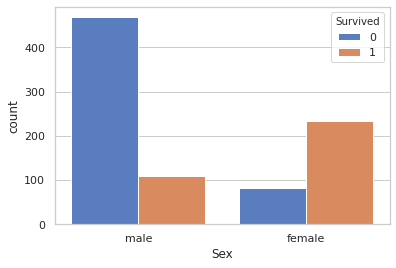

In [10]:
# Sex
sns.countplot(x='Sex', hue='Survived', data=train);

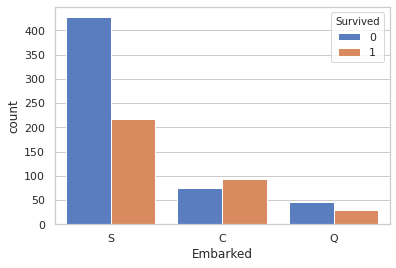

In [11]:
# Embarked
sns.countplot(x='Embarked', hue='Survived', data=train);

## <p style='color:blue'> Numerical Features </p>

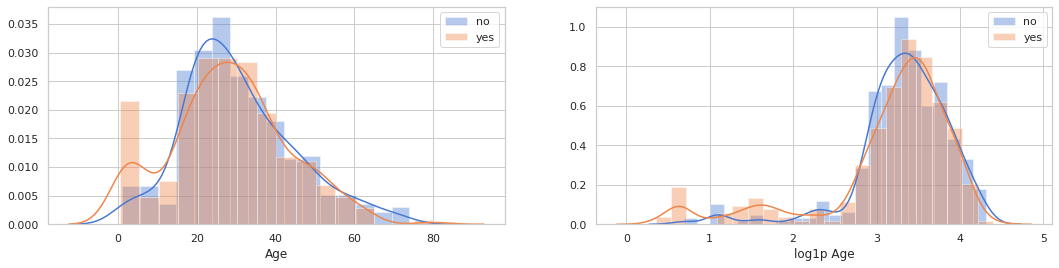

In [12]:
# Age
plot_dist(train, 'Age')

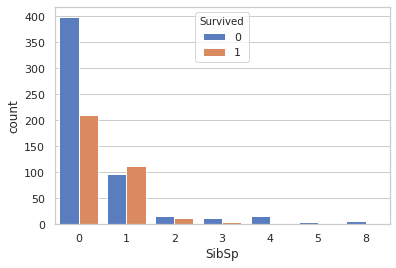

In [13]:
# SibSp
sns.countplot(x='SibSp', hue='Survived', data=train);

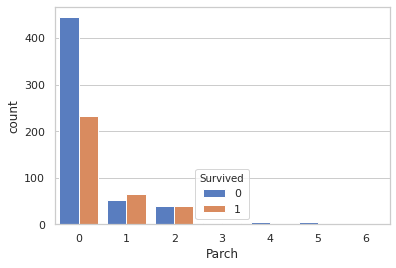

In [14]:
# Parch
# fig, ax = plt.subplots(figsize=(18,4))
sns.countplot(x='Parch', hue='Survived', data=train);

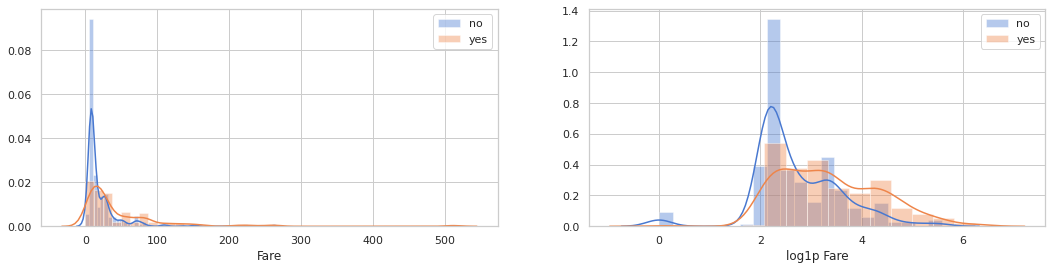

In [15]:
# Fare
plot_dist(train, 'Fare')

# Features Engineering

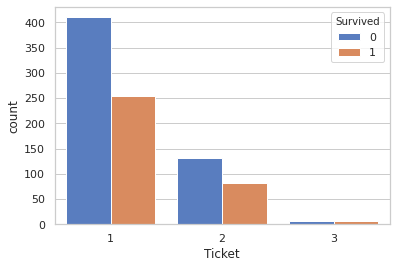

In [16]:
# Ticket
# Get the number of components separated by "space" in the ticket name
train['Ticket'] = train['Ticket'].apply(lambda x: len(x.split(' ')))
test['Ticket'] = test['Ticket'].apply(lambda x: len(x.split(' ')))
sns.countplot(x='Ticket', hue='Survived', data=train);

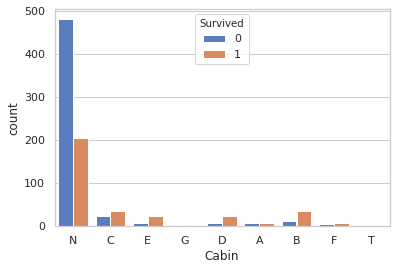

In [17]:
# Cabin

# Define NaN as a new category (n)
train['Cabin'].fillna('N', inplace=True)
test['Cabin'].fillna('N', inplace=True)

# Get the first letter of the cabin name
train['Cabin'] = train['Cabin'].apply(lambda x: x[0])
test['Cabin'] = test['Cabin'].apply(lambda x: x[0])
sns.countplot(x='Cabin', hue='Survived', data=train);

In [18]:
# Data Imputation

# Age
med = train['Age'].median()
train['Age'].fillna(med, inplace=True)
test['Age'].fillna(med, inplace=True)

# Fare (test data)
med = test['Fare'].median()
test['Fare'].fillna(med, inplace=True)

# Label Encoding

In [19]:
cols = ['Sex', 'Ticket', 'Cabin', 'Embarked']
for col in cols:
    encoding = {j:i for i,j in enumerate(train[col].unique())}
    train[col] = train[col].map(encoding).values
    test[col] = test[col].map(encoding).values

In [20]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,0,7.2500,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,0,71.2833,1,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,0,7.9250,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,1,53.1000,1,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,1,8.0500,0,0


# Correlation

In [21]:
corr = train.corr()
corr.style.background_gradient(cmap='coolwarm').set_precision(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,1.00,-0.01,-0.04,-0.04,0.03,-0.06,-0.00,0.07,0.01,0.04,-0.03
Survived,-0.01,1.00,-0.34,0.54,-0.06,-0.04,0.08,0.01,0.26,0.27,0.12
Pclass,-0.04,-0.34,1.00,-0.13,-0.34,0.08,0.02,0.13,-0.55,-0.56,0.03
Sex,-0.04,0.54,-0.13,1.00,-0.08,0.11,0.25,-0.01,0.18,0.11,0.13
Age,0.03,-0.06,-0.34,-0.08,1.00,-0.23,-0.17,-0.03,0.10,0.17,0.01
SibSp,-0.06,-0.04,0.08,0.11,-0.23,1.00,0.41,-0.11,0.16,-0.05,-0.06
Parch,-0.00,0.08,0.02,0.25,-0.17,0.41,1.00,-0.07,0.22,0.04,-0.08
Ticket,0.07,0.01,0.13,-0.01,-0.03,-0.11,-0.07,1.00,-0.21,-0.03,0.05
Fare,0.01,0.26,-0.55,0.18,0.10,0.16,0.22,-0.21,1.00,0.38,0.07
Cabin,0.04,0.27,-0.56,0.11,0.17,-0.05,0.04,-0.03,0.38,1.00,0.05


# One Hot Encoding

In [22]:
cols = ['Ticket', 'Cabin', 'Embarked']

# copy features
for col in cols:
    train[f'{col}_LE'] = train[col]
    test[f'{col}_LE'] = test[col]

train = pd.get_dummies(train, columns=cols)
test = pd.get_dummies(test, columns=cols)

In [23]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Ticket_LE', 'Cabin_LE', 'Embarked_LE', 'Ticket_0',
       'Ticket_1', 'Ticket_2', 'Cabin_0', 'Cabin_1', 'Cabin_2', 'Cabin_3',
       'Cabin_4', 'Cabin_5', 'Cabin_6', 'Cabin_7', 'Cabin_8', 'Embarked_0',
       'Embarked_1', 'Embarked_2', 'Embarked_3'],
      dtype='object')

In [24]:
# correlation
corr = train.corr()
corr.style.background_gradient(cmap='coolwarm').set_precision(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Ticket_LE,Cabin_LE,Embarked_LE,Ticket_0,Ticket_1,Ticket_2,Cabin_0,Cabin_1,Cabin_2,Cabin_3,Cabin_4,Cabin_5,Cabin_6,Cabin_7,Cabin_8,Embarked_0,Embarked_1,Embarked_2,Embarked_3
PassengerId,1.00,-0.01,-0.04,-0.04,0.03,-0.06,-0.00,0.01,0.07,0.04,-0.03,-0.07,0.07,0.00,-0.02,-0.04,0.04,-0.06,0.02,-0.00,0.07,-0.04,-0.01,0.02,-0.00,-0.03,0.00
Survived,-0.01,1.00,-0.34,0.54,-0.06,-0.04,0.08,0.26,0.01,0.27,0.12,-0.00,-0.00,0.02,-0.32,0.11,0.15,0.02,0.15,0.02,0.18,0.06,-0.03,-0.16,0.17,0.00,0.06
Pclass,-0.04,-0.34,1.00,-0.13,-0.34,0.08,0.02,-0.55,0.13,-0.56,0.03,-0.12,0.09,0.09,0.73,-0.42,-0.23,0.06,-0.28,-0.20,-0.37,0.01,-0.05,0.08,-0.24,0.22,-0.07
Sex,-0.04,0.54,-0.13,1.00,-0.08,0.11,0.25,0.18,-0.01,0.11,0.13,-0.01,0.03,-0.07,-0.14,0.06,0.05,0.09,0.08,-0.08,0.11,0.01,-0.02,-0.13,0.08,0.07,0.06
Age,0.03,-0.06,-0.34,-0.08,1.00,-0.23,-0.17,0.10,-0.03,0.17,0.01,0.03,-0.03,-0.01,-0.24,0.12,0.12,-0.08,0.14,0.12,0.10,-0.08,0.04,-0.01,0.03,-0.03,0.08
SibSp,-0.06,-0.04,0.08,0.11,-0.23,1.00,0.41,0.16,-0.11,-0.05,-0.06,0.10,-0.09,-0.05,0.04,0.03,-0.04,-0.00,-0.02,-0.05,-0.03,0.00,-0.02,0.07,-0.06,-0.03,-0.02
Parch,-0.00,0.08,0.02,0.25,-0.17,0.41,1.00,0.22,-0.07,0.04,-0.08,0.06,-0.04,-0.06,-0.04,0.03,-0.02,0.07,-0.02,-0.04,0.06,0.02,-0.02,0.06,-0.01,-0.08,-0.02
Fare,0.01,0.26,-0.55,0.18,0.10,0.16,0.22,1.00,-0.21,0.38,0.07,0.20,-0.18,-0.06,-0.48,0.36,0.05,-0.03,0.10,0.02,0.39,-0.03,0.00,-0.17,0.27,-0.12,0.05
Ticket_LE,0.07,0.01,0.13,-0.01,-0.03,-0.11,-0.07,-0.21,1.00,-0.03,0.05,-0.96,0.85,0.33,0.04,-0.02,-0.02,-0.04,0.03,0.01,-0.06,0.02,0.02,0.03,-0.14,0.14,0.02
Cabin_LE,0.04,0.27,-0.56,0.11,0.17,-0.05,0.04,0.38,-0.03,1.00,0.05,0.02,-0.01,-0.03,-0.82,0.03,0.13,0.08,0.34,0.30,0.67,0.42,0.13,-0.11,0.19,-0.11,0.14


# Models

In [25]:
# target
y_train = train['Survived']

# features
X_train = train.drop(['Survived'], axis=1)
X_test = test

In [26]:
len(X_train.columns), len(X_test.columns)

(27, 25)

In [27]:
[i for i in X_train.columns if i not in X_test.columns]

['Cabin_8', 'Embarked_3']

## <p style='color:blue'> Logistic Regression </p>

In [28]:
# drop some features
X_train.drop(['PassengerId', 'Name', 'Cabin_8', 'Embarked_3'], axis=1, inplace=True)
X_test.drop(['PassengerId', 'Name'], axis=1, inplace=True)

# scale features
for col in X_train.columns:
    min_ = X_train[col].min()
    max_ = X_test[col].max()
    intv = max_ - min_
    X_train[col] = (X_train[col] - min_) / intv
    X_test[col] = (X_test[col] - min_) / intv

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [30]:
def CV_Logistic_Regression(X_train, y_train, X_test, n_folds=5):
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 99)
    
    # Create oof sets for prediction storage.
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros((X_test.shape[0], n_folds))
    
    # Emptly list to store accuracy for each fold
    fold_acc = []

    for ifold, (tr_index, val_index) in enumerate(kf.split(X = X_train, y = y_train)):

        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[tr_index,:]
        X_val = X_train.iloc[val_index,:]
        y_tr = y_train[tr_index]
        y_val = y_train[val_index]

        # Train model
        model = LogisticRegression(random_state=0).fit(X_tr, y_tr)

        # Predict validation and test data and store them in oof sets.
        proba_val = model.predict_proba(X_val)[:,1]
        oof_train[val_index] = np.where(proba_val>0.5, 1, 0)
        proba_test = model.predict_proba(X_test)[:,1]
        oof_test[:, ifold] = np.where(proba_test>0.5, 1, 0)
        
        # Accuracy
        acc = accuracy_score(y_val, oof_train[val_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)

    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc = round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')
    
    return oof_train, oof_test, acc

In [31]:
oof_train_LogReg, oof_test_LogReg, acc_LogReg = CV_Logistic_Regression(X_train, y_train, X_test)

FOLD: 0 	 Acc: 0.782
FOLD: 1 	 Acc: 0.753
FOLD: 2 	 Acc: 0.826
FOLD: 3 	 Acc: 0.803
FOLD: 4 	 Acc: 0.792

MEAN Acc	: 0.791
ACTUAL Acc	: 0.791
STD Acc		: 0.024


## <p style='color:blue'> Support Vector Machine (SVM) </p>

In [32]:
from sklearn.svm import SVC

In [33]:
def CV_SVM(X_train, y_train, X_test, n_folds=5):
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 99)
    
    # Create oof sets for prediction storage.
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros((X_test.shape[0], n_folds))
    
    # Emptly list to store accuracy for each fold
    fold_acc = []

    for ifold, (tr_index, val_index) in enumerate(kf.split(X = X_train, y = y_train)):

        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[tr_index,:]
        X_val = X_train.iloc[val_index,:]
        y_tr = y_train[tr_index]
        y_val = y_train[val_index]

        # Train model
        model = SVC()
        model.fit(X_tr, y_tr)

        # Predict validation and test data and store them in oof sets.
        oof_train[val_index] = model.predict(X_val)
        oof_test[:, ifold] = model.predict(X_test)
        
        # Accuracy
        acc = accuracy_score(y_val, oof_train[val_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)

    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc =round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')
    
    return oof_train, oof_test, acc

In [34]:
oof_train_SVM, oof_test_SVM, acc_SVM = CV_SVM(X_train, y_train, X_test)

FOLD: 0 	 Acc: 0.771
FOLD: 1 	 Acc: 0.719
FOLD: 2 	 Acc: 0.826
FOLD: 3 	 Acc: 0.787
FOLD: 4 	 Acc: 0.798

MEAN Acc	: 0.78
ACTUAL Acc	: 0.78
STD Acc		: 0.035


## <p style='color:blue'> Decision Tree </p>

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
def CV_Decision_Tree(X_train, y_train, X_test, n_folds=5):
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 99)
    
    # Create oof sets for prediction storage.
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros((X_test.shape[0], n_folds))
    
    # Emptly list to store accuracy for each fold
    fold_acc = []

    for ifold, (tr_index, val_index) in enumerate(kf.split(X = X_train, y = y_train)):

        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[tr_index,:]
        X_val = X_train.iloc[val_index,:]
        y_tr = y_train[tr_index]
        y_val = y_train[val_index]

        # Train model
        model = DecisionTreeClassifier(random_state=0)
        model.fit(X_tr, y_tr)

        # Predict validation and test data and store them in oof sets.
        oof_train[val_index] = model.predict(X_val)
        oof_test[:, ifold] = model.predict(X_test)
        
        # Accuracy
        acc = accuracy_score(y_val, oof_train[val_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)

    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc = round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')
    
    return oof_train, oof_test, acc

In [37]:
oof_train_DecisionTree, oof_test_DecisionTree, acc_DecisionTree = CV_Decision_Tree(X_train, y_train, X_test)

FOLD: 0 	 Acc: 0.804
FOLD: 1 	 Acc: 0.792
FOLD: 2 	 Acc: 0.798
FOLD: 3 	 Acc: 0.758
FOLD: 4 	 Acc: 0.736

MEAN Acc	: 0.778
ACTUAL Acc	: 0.778
STD Acc		: 0.026


### <p style='color:blue'> Random Forest </p>

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
def CV_Random_Forest(X_train, y_train, X_test, n_folds=5):
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 99)
    
    # Create oof sets for prediction storage.
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros((X_test.shape[0], n_folds))
    
    # Emptly list to store accuracy for each fold
    fold_acc = []

    for ifold, (tr_index, val_index) in enumerate(kf.split(X = X_train, y = y_train)):

        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[tr_index,:]
        X_val = X_train.iloc[val_index,:]
        y_tr = y_train[tr_index]
        y_val = y_train[val_index]

        # Train model
        model = RandomForestClassifier(max_depth=5, random_state=0)
        model.fit(X_tr, y_tr)

        # Predict validation and test data and store them in oof sets.
        oof_train[val_index] = model.predict(X_val)
        oof_test[:, ifold] = model.predict(X_test)
        
        # Accuracy
        acc = accuracy_score(y_val, oof_train[val_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)

    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc = round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')
    
    return oof_train, oof_test, acc

In [40]:
oof_train_RandomForest, oof_test_RandomForest, acc_RandomForest = CV_Random_Forest(X_train, y_train, X_test)

FOLD: 0 	 Acc: 0.760
FOLD: 1 	 Acc: 0.820
FOLD: 2 	 Acc: 0.865
FOLD: 3 	 Acc: 0.792
FOLD: 4 	 Acc: 0.798

MEAN Acc	: 0.807
ACTUAL Acc	: 0.807
STD Acc		: 0.035


## <p style='color:blue'> Artificial Neural Networks </p>

In [41]:
import tensorflow as tf

In [42]:
def build_model(Nfeatures):
    tf.keras.backend.clear_session()
    # set random seed for reproducibility
    tf.random.set_seed(99)

    # define a model
    model = tf.keras.Sequential()

    # add the first hidden layer
    model.add(tf.keras.layers.Dense(units = 8, activation = 'linear', input_dim = Nfeatures))
    
#     # add regularization
#     model.add(tf.keras.layers.Dropout(0.2))

#     # add the second hidden layer
#     model.add(tf.keras.layers.Dense(units = 16, activation = 'linear'))
    
#     # add regularization
#     model.add(tf.keras.layers.Dropout(0.2))
    
    # add the output layer
    model.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

    # compile the model
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy']) 
    
    return model

In [43]:
model = build_model(X_train.shape[1])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 8)                 192       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 9         
Total params: 201
Trainable params: 201
Non-trainable params: 0
_________________________________________________________________


In [44]:
def CV_ANN(X_train, y_train, X_test, n_folds=5, seed=99):
    
    # Kfold split
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = seed)

    # Create oof sets for prediction storage.
    oof_train = np.zeros((X_train.shape[0]))
    oof_test = np.zeros((X_test.shape[0], n_folds))
    
    # Save all models validation accuracy
    fold_acc = []
    
    # Define early stopping
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)
        
    for ifold, (train_index, valid_index) in enumerate(kf.split(X=X_train, y=y_train)):
        
        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[train_index,:]
        X_val = X_train.iloc[valid_index,:]
        y_tr = y_train[train_index]
        y_val = y_train[valid_index]
        
        # Restart model
        model = build_model(X_tr.shape[1])
        
        # Train model
        model.fit(
            X_tr,
            y_tr,
            batch_size = 8,
            epochs = 100,
            validation_data = (X_val, y_val),
            verbose = 0,
            callbacks = [earlystop])
        
        # Prediction on validation data and store them in oof (out of folds) sets
        oof_train[valid_index] = np.where(model.predict(X_val)[:,0]>0.5, 1, 0)
        oof_test[:, ifold] = np.where(model.predict(X_test)[:,0]>0.5, 1, 0)
        
        # Accuracy
        acc = accuracy_score(y_val, oof_train[valid_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)
             
    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc = round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')

    return oof_train, oof_test, acc

In [45]:
oof_train_ANN, oof_test_ANN, acc_ANN = CV_ANN(X_train, y_train, X_test)

FOLD: 0 	 Acc: 0.771
FOLD: 1 	 Acc: 0.803
FOLD: 2 	 Acc: 0.831
FOLD: 3 	 Acc: 0.815
FOLD: 4 	 Acc: 0.787

MEAN Acc	: 0.801
ACTUAL Acc	: 0.801
STD Acc		: 0.021


## <p style='color:blue'> Gradient Boosted Trees with LGBM </p>

In [46]:
import lightgbm as lgb

In [47]:
def CV_LGBM(X_train, y_train, X_test, n_folds=5, early_stop=None):
    kf = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 99)
    
    # Create oof sets for prediction storage.
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros((X_test.shape[0], n_folds))

    gbm_history, fi, fold_acc = {}, [], []
    
    for ifold, (tr_index, val_index) in enumerate(kf.split(X = X_train, y = y_train)):

        # Create train and validation sets based on KFold indices.
        X_tr = X_train.iloc[tr_index,:]
        X_val = X_train.iloc[val_index,:]
        y_tr = y_train[tr_index]
        y_val = y_train[val_index]

        dtrain = lgb.Dataset(X_tr, y_tr)
        dvalid = lgb.Dataset(X_val, y_val)

        # Train LightGBM model
        params ={
            'task': 'train',
            'boosting': 'gbdt',
            'nthread': 2,
            'objective': 'binary',
            'metrics': 'binary',
            'learning_rate': 0.01,
            'num_leaves': 7,
            'max_depth': 20,
            'min_data_in_leaf': 100,
            'seed': 0,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.6,
            'bagging_freq': 1,
            'verbose': -1}
        model = lgb.train(params = params, train_set = dtrain, evals_result = gbm_history, 
                          num_boost_round = 100000, valid_sets = [dtrain, dvalid], 
                          early_stopping_rounds = early_stop, verbose_eval = 0)

        # Predict validation and test data and store them in oof sets.
        proba_train = model.predict(X_val, num_iteration = model.best_iteration)
        oof_train[val_index] = np.where(proba_train > 0.5, 1, 0)
        proba_test = model.predict(X_test, num_iteration = model.best_iteration)
        oof_test[:, ifold] = np.where(proba_test > 0.5, 1, 0)

        # feature importance
        fi.append(model.feature_importance())
    
        # Accuracy
        acc = accuracy_score(y_val, oof_train[val_index])
        
        print('FOLD: {} \t Acc: {:.3f}'.format(ifold, acc))
            
        fold_acc.append(acc)
             
    print(f'\nMEAN Acc\t: {round(np.mean(fold_acc), 3)}')
    acc = round(accuracy_score(y_train, oof_train), 3)
    print(f'ACTUAL Acc\t: {acc}')
    print(f'STD Acc\t\t: {round(np.std(fold_acc), 3)}')
    
    return oof_train, oof_test, acc, fi

In [48]:
# drop one-hot-encoding
dropf = ['Ticket_0', 'Ticket_1', 'Ticket_2', 'Cabin_0', 'Cabin_1', 'Cabin_2', 'Cabin_3', 'Cabin_4', 'Cabin_5',
         'Cabin_6', 'Cabin_7', 'Embarked_0', 'Embarked_1', 'Embarked_2']

In [49]:
oof_train_LGBM, oof_test_LGBM, acc_LGBM, fi = CV_LGBM(X_train.drop(dropf, axis=1), 
                                            y_train, X_test.drop(dropf, axis=1), 
                                            early_stop=200)

FOLD: 0 	 Acc: 0.799
FOLD: 1 	 Acc: 0.798
FOLD: 2 	 Acc: 0.860
FOLD: 3 	 Acc: 0.809
FOLD: 4 	 Acc: 0.798

MEAN Acc	: 0.813
ACTUAL Acc	: 0.813
STD Acc		: 0.024


In [50]:
usecols = [f for f in X_train.columns if f not in dropf]
Imp_feats = {}
mean_vals = np.mean(fi,axis=0)
for col, val in zip(usecols, mean_vals):
    Imp_feats.update({col: val})

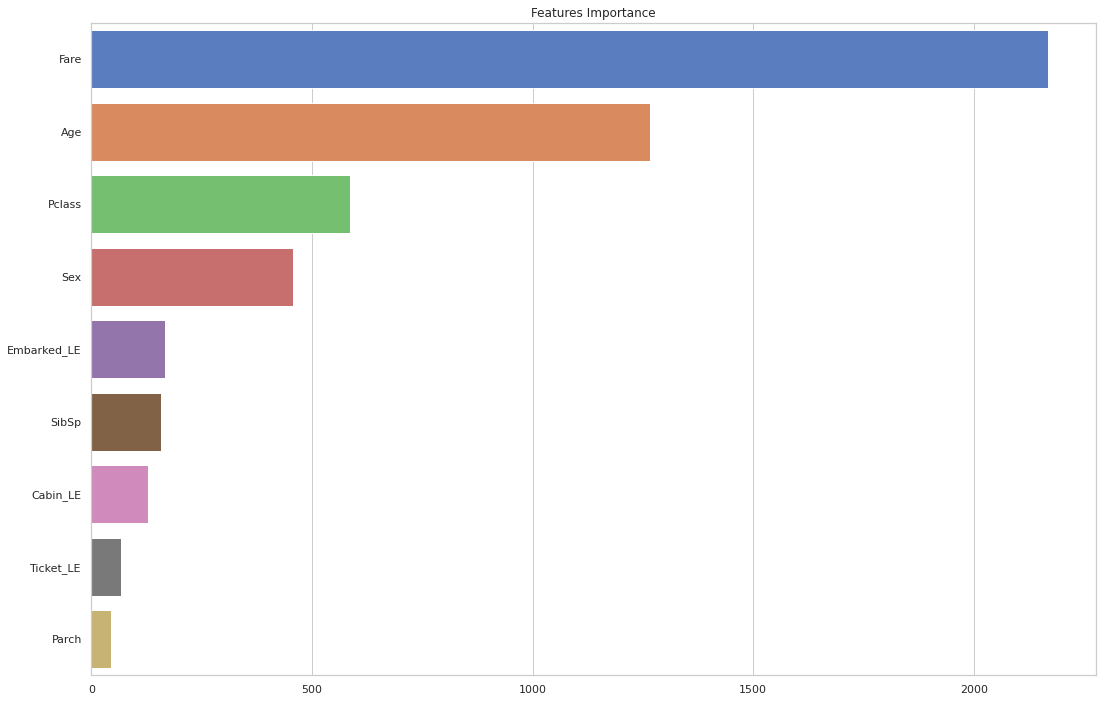

In [51]:
data = pd.Series(Imp_feats).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(18,12))
sns.barplot(data.values, data.index, ax=ax)
ax.set_title('Features Importance');

# Summary

In [52]:
results = {
    'Logistic_Regression': acc_LogReg,
    'SVM': acc_SVM,
    'Decision Tree': acc_DecisionTree,
    'Random Forest': acc_RandomForest,
    'Neural Networks': acc_ANN,
    'LGBM': acc_LGBM
}
pd.Series(results)

Logistic_Regression    0.791
SVM                    0.780
Decision Tree          0.778
Random Forest          0.807
Neural Networks        0.801
LGBM                   0.813
dtype: float64

# Submission

In [53]:
submit = pd.read_csv('../input/titanic/gender_submission.csv')
submit.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [54]:
pred = np.mean(oof_test_LGBM, axis=1)
submit['Survived'] = np.where(pred>0.5, 1, 0)

In [55]:
submit.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [56]:
# save
submit.to_csv("pred.csv", index=False)